In [1]:
import numpy as np
from time import time
# from numba import njit, prange
import matplotlib.pyplot as plt
from matplotlib import text
import matplotlib
%matplotlib inline

import shutil
from scipy import ndimage
from matplotlib.colors import LogNorm
import glob
from collections import defaultdict
import json
import os
from scipy.optimize import curve_fit

In [2]:
colors = ["#12a182", "#525288", "#cc163a", "#1177b0", "#f26b1f", "black"]

In [3]:
matplotlib.rcParams['font.family'] = 'Times New Roman'

matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{mathptmx}'



In [18]:
output_512h2o = np.loadtxt("512_h2o/output.dat")
output_4096h2o = np.loadtxt("4096_h2o/output.dat")

In [4]:
output_32gpu = np.loadtxt("32_GPU/output.dat")
# output_32gpu = np.r_[output_512h2o[-1:], output_4096h2o[-1:], output_32gpu]
# output_32gpu[0, 0] = 512
# output_32gpu[1, 0] = 4096

In [5]:
output_1bead = np.loadtxt("1bead_1GPU/output.dat")

In [6]:
output_175616h2o_2 = np.loadtxt("175616_h2o_ring_repair/output.dat")

In [7]:
output_175616h2o_1bead = np.loadtxt("175616_h2o_1bead/output.dat")

In [9]:
output_175616h2o_weak_2 = np.loadtxt("175616_h2o_weak_scaling_ring_repair/output.dat")
output_175616h2o_weak_2 = np.r_[output_175616h2o_2[0].reshape(1, -1), output_175616h2o_weak_2]

In [10]:
output_175616h2o_1bead_weak = np.loadtxt("175616_h2o_1bead_weak_scaling/output.dat")
output_175616h2o_1bead_weak = np.r_[output_175616h2o_1bead[0].reshape(1, -1), output_175616h2o_1bead_weak]

In [12]:
output_512h2o_ipi = []
output_512h2o_ipi_unix = []

output_4096h2o_ipi = []
output_4096h2o_ipi_unix = []

def parse_i_pi_output(nH2O, output_list, output_list_unix):
    with open(f"{nH2O:d}_h2o/i-pi.dat", "r") as f:
        for line_ in f.readlines():
            line = line_.split()
            # print(line[0])
            try:
                ngpu = int(line[0])
                unix = False
            except:
                try:
                    ngpu = int(line[0][:-5])
                    unix = True
                except:
                    ngpu = np.nan
                    # print("Not a line with ngpu")
                    continue
    
            if unix:
                output_list_unix.append([ngpu]+line[1:])
            else:
                output_list.append([ngpu]+line[1:])
    
    output_list = np.array(output_list).astype(float)
    output_list_unix = np.array(output_list_unix).astype(float)

    return output_list, output_list_unix
    
output_512h2o_ipi, output_512h2o_ipi_unix = parse_i_pi_output(512, output_512h2o_ipi, output_512h2o_ipi_unix)
output_4096h2o_ipi, output_4096h2o_ipi_unix = parse_i_pi_output(4096, output_4096h2o_ipi, output_4096h2o_ipi_unix)

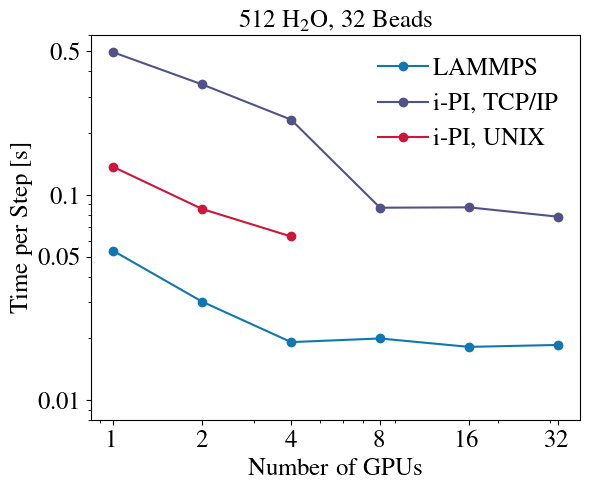

In [21]:
plt.figure(figsize=(6, 5))

plt.title("512 H$_2$O, 32 Beads", fontsize=18)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of GPUs", fontsize=18)
plt.ylabel("Time per Step [s]", fontsize=18)

plt.xticks([1, 2, 4, 8, 16, 32, 100], [1, 2, 4, 8, 16, 32, 100], fontsize=18)
# plt.yticks([1e-2, 2e-2, 3e-2, 4e-2, 5e-2, 6e-2], [1e-2, 2e-2, 3e-2, 4e-2, 5e-2, 6e-2], fontsize=18)
plt.yticks([0.01, 0.05, 0.1, 0.5], [0.01, 0.05, 0.1, 0.5], fontsize=18)

plt.ylim(0.008, 0.6)

plt.plot(output_512h2o[:, 0], output_512h2o[:, 5], marker="o", color=colors[3], label="LAMMPS")
plt.plot(output_512h2o_ipi[:, 0], output_512h2o_ipi[:, 5], marker="o", color=colors[1], label="i-PI, TCP/IP")
plt.plot(output_512h2o_ipi_unix[:, 0], output_512h2o_ipi_unix[:, 5], marker="o", color=colors[2], label="i-PI, UNIX")
# plt.plot(output_512h2o[:, 0], output_512h2o[0, 5]/output_512h2o[:, 0], linestyle="--", color="grey")

plt.legend(fontsize=18, handletextpad=0.2, edgecolor="None", facecolor="None")
plt.tight_layout()
plt.savefig("512H2O.pdf")

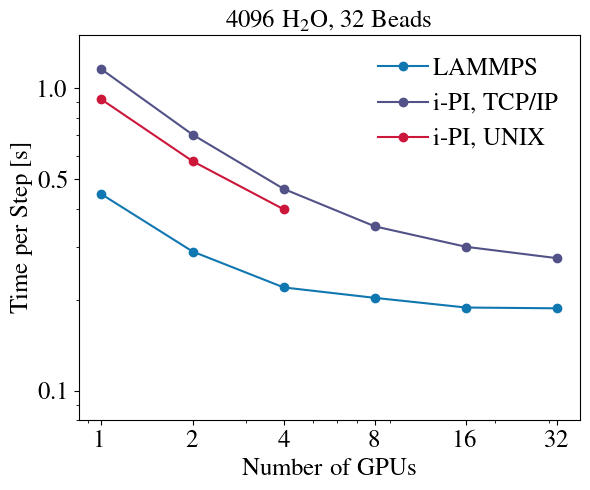

In [22]:
plt.figure(figsize=(6, 5))

plt.title("4096 H$_2$O, 32 Beads", fontsize=18)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of GPUs", fontsize=18)
plt.ylabel("Time per Step [s]", fontsize=18)

plt.xticks([1, 2, 4, 8, 16, 32, 100], [1, 2, 4, 8, 16, 32, 100], fontsize=18)
# plt.yticks(np.arange(0.1, 1.2, 0.1), [f"{i:.1f}" for i in np.arange(0.1, 1.2, 0.1)], fontsize=18)
plt.yticks([0.1, 0.5, 1.0], [0.1, 0.5, 1.0], fontsize=18)

plt.ylim(0.08, 1.5)

plt.plot(output_4096h2o[:, 0], output_4096h2o[:, 5], marker="o", color=colors[3], label="LAMMPS")
plt.plot(output_4096h2o_ipi[:, 0], output_4096h2o_ipi[:, 5], marker="o", color=colors[1], label="i-PI, TCP/IP")
plt.plot(output_4096h2o_ipi_unix[:, 0], output_4096h2o_ipi_unix[:, 5], marker="o", color=colors[2], label="i-PI, UNIX")
# plt.plot(output_4096h2o[:, 0], output_4096h2o[0, 5]/output_4096h2o[:, 0], linestyle="--", color="grey")

plt.legend(fontsize=18, handletextpad=0.2, edgecolor="None", facecolor="None")
plt.tight_layout()
plt.savefig("4096H2O.pdf")

In [23]:
def nsperday(sperstep):
    return (3600*24 / sperstep) / 2e6

In [24]:
nsperday(output_512h2o[:, 5])

array([0.80898876, 1.43046358, 2.25      , 2.16      , 2.37362637,
       2.32258065])

In [25]:
nsperday(output_512h2o_ipi[:, 5])

array([0.08723396, 0.1250579 , 0.18566271, 0.49832737, 0.49626651,
       0.5510907 ])

In [26]:
nsperday( output_4096h2o_ipi[:, 5])

array([0.03733278, 0.06140463, 0.09284732, 0.12347443, 0.14425485,
       0.15731974])

In [27]:
nsperday( output_4096h2o[:, 5])

array([0.0966443 , 0.14953271, 0.19654231, 0.21280788, 0.2290562 ,
       0.2304    ])

In [29]:
nH2O = [512*i**3 for i in range(1, 8)]
nH2O_label = [f"${i}^3$" for i in range(1, 8)]

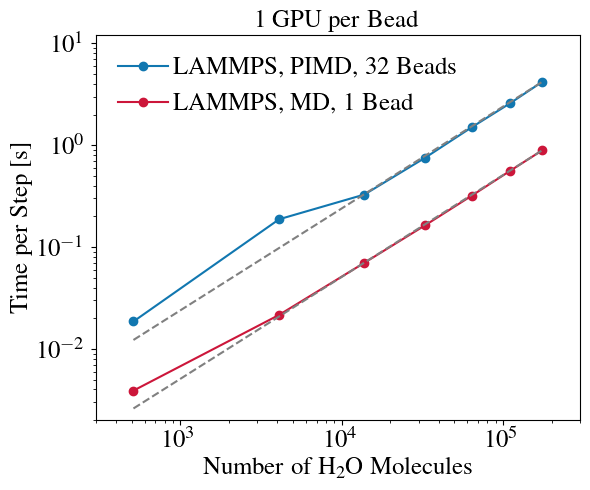

In [32]:
plt.figure(figsize=(6, 5))

plt.title("1 GPU per Bead", fontsize=18)

plt.xscale("log")
plt.yscale("log")

# plt.xlabel("Number of H$_2$O Molecules / 512", fontsize=18)
plt.xlabel("Number of H$_2$O Molecules", fontsize=18)
plt.ylabel("Time per Step [s]", fontsize=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# plt.xticks(nH2O, nH2O, fontsize=18)
# plt.yticks(np.arange(0.1, 1.2, 0.1), [f"{i:.1f}" for i in np.arange(0.1, 1.2, 0.1)], fontsize=18)
# plt.yticks([0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5, 10], [0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5, 10], fontsize=18)

plt.xlim(3e2, 3e5)
plt.ylim(0.002, 12)

# output_32gpu_fit = np.polyfit(output_32gpu[:, 0], output_32gpu[:, 5], deg=1)
# output_1bead_fit = np.polyfit(output_1bead[:, 0], output_1bead[:, 5], deg=1)

plt.plot(output_32gpu[:, 0], output_32gpu[:, 5], marker="o", color=colors[3], label="LAMMPS, PIMD, 32 Beads")
plt.plot(output_1bead[:, 0], output_1bead[:, 5], marker="o", color=colors[2], label="LAMMPS, MD, 1 Bead")

# plt.plot(np.arange(output_32gpu[-1, 0]), np.arange(output_32gpu[-1, 0]) * output_32gpu_fit[0] + output_32gpu_fit[1], linestyle="--", color="grey")
# plt.plot(np.arange(output_1bead[-1, 0]), np.arange(output_1bead[-1, 0]) * output_1bead_fit[0] + output_1bead_fit[1], linestyle="--", color="grey")

plt.plot(output_32gpu[:, 0], output_32gpu[-1, 5]*np.array(nH2O[:len(output_32gpu[:, 0])])/nH2O[-1], linestyle="--", color="grey")
plt.plot(output_1bead[:, 0], output_1bead[-1, 5]*np.array(nH2O[:len(output_1bead[:, 0])])/nH2O[-1], linestyle="--", color="grey")
# plt.plot(output_32gpu[:, 0], output_32gpu[0, 5]*np.array(nH2O[:len(output_32gpu[:, 0])])/512, linestyle="--", color="grey", label="linear scaling")

# plt.plot(output_4096h2o_ipi[:, 0], output_4096h2o_ipi[:, 5], marker="o", color=colors[1], label="i-PI, TCP/IP")
# plt.plot(output_4096h2o_ipi_unix[:, 0], output_4096h2o_ipi_unix[:, 5], marker="o", color=colors[2], label="i-PI, UNIX")
# plt.plot(output_4096h2o[:, 0], output_4096h2o[0, 5]/output_4096h2o[:, 0], linestyle="--", color="grey")

plt.legend(fontsize=18, handletextpad=0.2, edgecolor="None", facecolor="None")
plt.tight_layout()
plt.savefig("1GPU_per_Bead.pdf")


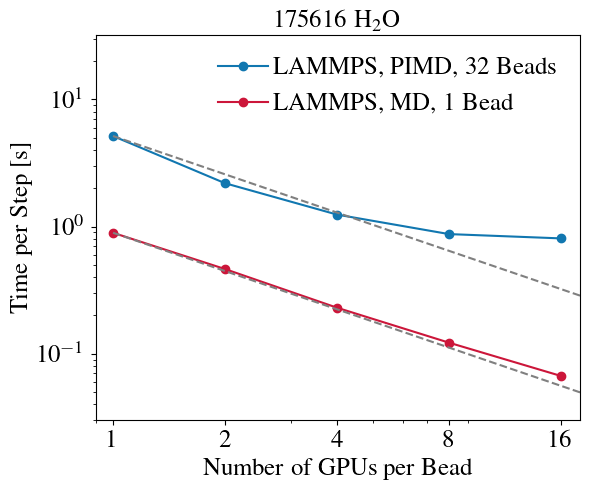

In [33]:
plt.figure(figsize=(6, 5))

plt.title("175616 H$_2$O", fontsize=18)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of GPUs per Bead", fontsize=18)
plt.ylabel("Time per Step [s]", fontsize=18)

plt.xticks([1, 2, 4, 8, 16], [1, 2, 4, 8, 16], fontsize=18)
plt.yticks(fontsize=18)
# plt.yticks(np.arange(0.1, 1.2, 0.1), [f"{i:.1f}" for i in np.arange(0.1, 1.2, 0.1)], fontsize=18)
# plt.yticks([0.1, 0.5, 1.0], [0.1, 0.5, 1.0], fontsize=18)

plt.xlim(0.9, 18)
plt.ylim(0.03, 32)

# plt.plot(output_175616h2o[:, 0], output_175616h2o[:, 5], marker="o", color=colors[3], label="LAMMPS, PIMD, 32 Beads")

plt.plot(output_175616h2o_2[:, 0], output_175616h2o_2[:, 5], marker="o", color=colors[3], label="LAMMPS, PIMD, 32 Beads")
plt.plot(output_175616h2o_1bead[:, 0], output_175616h2o_1bead[:, 5], marker="o", color=colors[2], label="LAMMPS, MD, 1 Bead")
# plt.plot(output_175616h2o_ipi[:, 0], output_175616h2o_ipi[:, 5], marker="o", color=colors[1], label="i-PI, TCP/IP")
# plt.plot(output_175616h2o_ipi_unix[:, 0], output_175616h2o_ipi_unix[:, 5], marker="o", color=colors[2], label="i-PI, UNIX")
# plt.plot(output_175616h2o[:, 0], output_175616h2o[0, 5]/output_175616h2o[:, 0], linestyle="--", color="grey")

plt.plot(np.array([1, 100]), output_175616h2o_2[0, 5]/np.array([1, 100]), linestyle="--", color="grey")
plt.plot(np.array([1, 100]), output_175616h2o_1bead[0, 5]/np.array([1, 100]), linestyle="--", color="grey")
# plt.xticks([1, 2, 4, 8], [1, 2, 4, 8], fontsize=18)


plt.legend(fontsize=18, handletextpad=0.2, edgecolor="None", facecolor="None")
plt.tight_layout()
plt.savefig("175616H2O.pdf")

In [35]:
output_175616h2o_2[0, 5]/output_175616h2o_2[:, 5]/output_175616h2o_2[:, 0]

array([1.        , 1.1752394 , 1.03739333, 0.73839675, 0.39916057])

In [36]:
output_175616h2o_1bead[0, 5]/output_175616h2o_1bead[:, 5]/output_175616h2o_1bead[:, 0]

array([1.        , 0.96470207, 0.97141304, 0.91492629, 0.83617141])

In [37]:
Natoms = [f"{i:.2f}M" for i in 175616*3*np.array([1, 2, 4, 8, 16])/1e6]

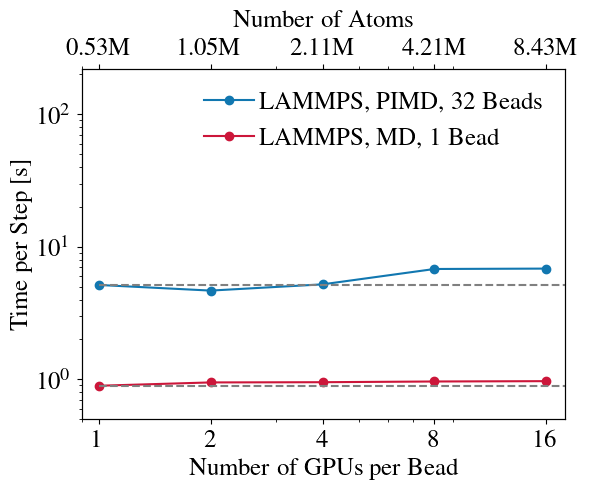

In [38]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Number of GPUs per Bead", fontsize=18)
ax.set_ylabel("Time per Step [s]", fontsize=18)

xtick_pos = np.array([1, 2, 4, 8, 16])
Natoms = [f"{i:.2f}M" for i in 175616 * 3 * xtick_pos / 1e6]

ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_pos, fontsize=18)

ax.tick_params(axis="y", labelsize=18)

ax.set_xlim(0.9, 18)
ax.set_ylim(0.5, 220)

# ax.plot(output_175616h2o_weak[:, 0],
#         output_175616h2o_weak[:, 5],
#         marker="o", color=colors[3],
#         label="LAMMPS, PIMD, 32 Beads")

ax.plot(output_175616h2o_weak_2[:, 0],
        output_175616h2o_weak_2[:, 5],
        marker="o", color=colors[3],
        label="LAMMPS, PIMD, 32 Beads")

ax.plot(output_175616h2o_1bead_weak[:, 0],
        output_175616h2o_1bead_weak[:, 5],
        marker="o", color=colors[2],
        label="LAMMPS, MD, 1 Bead")

# ax.plot([1, 100], output_175616h2o_weak[0, 5]*np.ones(2), linestyle="--", color="grey")

ax.plot([1, 100], output_175616h2o_weak_2[0, 5]*np.ones(2), linestyle="--", color="grey")
ax.plot([1, 100], output_175616h2o_1bead_weak[0, 5]*np.ones(2), linestyle="--", color="grey")
# ax.plot([1, 100], output_175616h2o_weak[0, 5]*np.array([1, 100]), linestyle="--", color="dimgrey")

ax.legend(fontsize=18, handletextpad=0.2, edgecolor="None", facecolor="None", loc="upper right")

ax_top = ax.twiny()
ax_top.set_xscale("log")

ax_top.set_xlim(ax.get_xlim())          # critical: keep alignment
ax_top.set_xticks(xtick_pos)
ax_top.set_xticklabels(Natoms, fontsize=18)

ax_top.set_xlabel("Number of Atoms", fontsize=18, labelpad=8)

plt.tight_layout()
plt.savefig("weak_scaling.pdf")

In [40]:
output_175616h2o_1bead_weak[0, 5] / output_175616h2o_1bead_weak[:, 5]

array([1.        , 0.943717  , 0.94014307, 0.92851948, 0.92314844])

In [41]:
output_175616h2o_weak_2[0, 5] / output_175616h2o_weak_2[:, 5]

array([1.        , 1.10308445, 0.98968326, 0.75772621, 0.75257161])